## Notebook for generating Gaussian input files from SMILES

In [1]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import AllChem, Draw, Descriptors, rdMolDescriptors, PandasTools
from rdkit.Chem.Draw import IPythonConsole
IPythonConsole.ipython_3d = True
IPythonConsole.ipython_useSVG=True  # Use higher quality images for molecules
import py3Dmol ## not used
import nglview as nv
from pymatgen.io.gaussian import Molecule, GaussianInput, GaussianOutput
from pymatgen.io.xyz import XYZ
from ase.visualize import view
from ase import Atoms
from ase.io import read, write
# from ase.calculators.xtb import XTB
from xtb_ase import XTB
from ase.optimize import BFGS
import tempfile, shutil, subprocess, os, sys
import glob
from math import sqrt
import random
from scipy.spatial import cKDTree

/Users/riteshkumar/codes/anaconda3/lib/python3.13/site-packages/nglview/__init__.py:12: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
%%bash
pwd
ls -ltr

/Users/riteshkumar/Library/CloudStorage/Box-Box/Research-postdoc/Electrolyte_ML_MD-DFT/DFT-calcs
total 440
-rw-------@   1 riteshkumar  staff  866707 Sep  4 11:50 calc_li_bind_all.ipynb
-rw-------@   1 riteshkumar  staff  382751 Sep  4 11:50 extract_homo_lumo.ipynb
-rw-r--r--@   1 riteshkumar  staff    7316 Sep  4 12:23 solvent_search_space_all_090425.csv
-rw-------@   1 riteshkumar  staff   32276 Sep  4 16:44 gen_esp_input_gaussian.ipynb
-rw-r--r--@   1 riteshkumar  staff     123 Sep  7 18:16 xtb.inp
-rw-r--r--@   1 riteshkumar  staff     477 Sep  7 18:16 coord.xyz
-rw-r--r--@   1 riteshkumar  staff      74 Sep  7 18:16 energy
-rw-r--r--@   1 riteshkumar  staff    1206 Sep  7 18:16 gradient
-rw-r--r--@   1 riteshkumar  staff    1074 Sep  7 18:16 coord.engrad
-rw-r--r--@   1 riteshkumar  staff     120 Sep  7 18:16 charges
-rw-r--r--@   1 riteshkumar  staff     459 Sep  7 18:16 wbo
-rw-r--r--@   1 riteshkumar  staff     785 Sep  7 18:16 xtbtopo.mol
-rw-r--r--@   1 riteshkumar  staff    

In [2]:
def gen_3d_pos(smiles):
    mol = Chem.MolFromSmiles(smiles)
    mol3d = Chem.AddHs(mol)
    AllChem.EmbedMolecule(mol3d)
    AllChem.MMFFOptimizeMolecule(mol3d)
    conf = mol3d.GetConformer()
    # conf.GetAtomNumber()
    atomic_symbol_list = []
    for i in range(mol3d.GetNumAtoms()):
        # print(mol3d.GetAtomWithIdx(i).GetAtomicNum())
        # print(mol3d.GetAtomWithIdx(i).GetSymbol())
        atomic_symbol_list.append(mol3d.GetAtomWithIdx(i).GetSymbol())
    return conf.GetPositions(), atomic_symbol_list

def gen_3d_mol(smiles):
    mol = Chem.MolFromSmiles(smiles)
    mol3d = Chem.AddHs(mol)
    AllChem.EmbedMolecule(mol3d)
    AllChem.MMFFOptimizeMolecule(mol3d)
    return mol3d

In [3]:
def rdkit_best_conformer(smiles, n_confs=200, mmff_max_iters=200, seed=0xF00D):
    """Return (symbols, positions, mol, best_conf_id) for the lowest-energy RDKit conformer."""
    mol = Chem.AddHs(Chem.MolFromSmiles(smiles))
    params = AllChem.ETKDGv3()
    params.randomSeed = seed
    params.pruneRmsThresh = 0.2
    params.useSmallRingTorsions = True
    conf_ids = AllChem.EmbedMultipleConfs(mol, numConfs=n_confs, params=params)

    use_mmff = AllChem.MMFFHasAllMoleculeParams(mol)
    if use_mmff:
        res = AllChem.MMFFOptimizeMoleculeConfs(mol, numThreads=0, maxIters=mmff_max_iters)
        energies = np.array([r[1] for r in res])
    else:
        res = AllChem.UFFOptimizeMoleculeConfs(mol, numThreads=0, maxIters=mmff_max_iters)
        # UFF returns (converged, energy); energy is at index 1 as well
        energies = np.array([r[1] for r in res])

    best_idx = int(np.argmin(energies))
    best_conf_id = conf_ids[best_idx]
    conf = mol.GetConformer(best_conf_id)
    pos = conf.GetPositions()
    sym = [a.GetSymbol() for a in mol.GetAtoms()]
    return sym, pos, mol, best_conf_id

def _xtb_ase_parameters(charge=0, mult=1, steps=200, solvent=None):
    # $xcontrol section
    uhf = max(0, int(mult) - 1)
    xcontrol = {
        'charge': int(charge),
        'max_iterations': int(steps),
    }
    if uhf:
        xcontrol['uhf'] = uhf
    params = {'xcontrol': xcontrol}
    # $gbsa section
    if solvent:
        params['gbsa'] = {'solvent': str(solvent)}
    return params

def xtb_optimize(symbols, positions, charge=0, mult=1, solvent='thf', fmax=0.02, steps=200):
    atoms = Atoms(symbols=symbols, positions=positions)
    params = _xtb_ase_parameters(charge=charge, mult=mult, steps=steps, solvent=solvent)
    calc = XTB(method='GFN2-xTB', parameters=params)
    atoms.calc = calc
    dyn = BFGS(atoms, logfile=None)
    dyn.run(fmax=fmax, steps=steps)
    return atoms.get_positions()

def crest_best_geometry(symbols, positions, charge=0, solvent='thf', ncores=8):
    work = tempfile.mkdtemp(prefix='crest_')
    try:
        mol = Atoms(symbols=symbols, positions=positions)
        xyz_path = os.path.join(work, 'start.xyz')
        write(xyz_path, mol)
        cmd = ['crest', 'start.xyz', '-gfn2', '-T', str(ncores)]
        if solvent:
            cmd += ['-alpb', solvent]
        subprocess.run(cmd, cwd=work, check=True)
        best_path = os.path.join(work, 'crest_best.xyz')
        best = read(best_path)
        return best.get_positions()
    finally:
        shutil.rmtree(work, ignore_errors=True)

In [4]:
def fragment_smiles_list(smiles: str):
    return [s for s in smiles.split('.') if s.strip()]

def formal_charge_of_mol(mol):
    return sum([a.GetFormalCharge() for a in mol.GetAtoms()])

def best_conformer_fragment(smiles, n_confs=100):
    sym, pos, mol, cid = rdkit_best_conformer(smiles, n_confs=n_confs)
    q = formal_charge_of_mol(mol)
    return {'smiles': smiles, 'symbols': sym, 'positions': np.array(pos, dtype=float), 'charge': q}

def random_rotation_matrix():
    # Uniform random rotation
    u1,u2,u3 = random.random(), random.random(), random.random()
    import math
    q1 = math.sqrt(1-u1)*math.sin(2*math.pi*u2)
    q2 = math.sqrt(1-u1)*math.cos(2*math.pi*u2)
    q3 = math.sqrt(u1)*math.sin(2*math.pi*u3)
    q4 = math.sqrt(u1)*math.cos(2*math.pi*u3)
    # Quaternion to rotation matrix
    return np.array([
        [1-2*(q3*q3+q4*q4), 2*(q2*q3-q1*q4),     2*(q2*q4+q1*q3)],
        [2*(q2*q3+q1*q4),     1-2*(q2*q2+q4*q4), 2*(q3*q4-q1*q2)],
        [2*(q2*q4-q1*q3),     2*(q3*q4+q1*q2),   1-2*(q2*q2+q3*q3)]
    ])

def min_inter_fragment_distance(coords_a, coords_b):
    dmin = 1e9
    for a in coords_a:
        diff = coords_b - a
        dsq = np.sum(diff*diff, axis=1)
        m = dsq.min()
        if m < dmin:
            dmin = m
    return sqrt(dmin)

def place_fragments(frag_data, min_sep=3.2, max_tries=500):
    """
    Sequentially place fragments in space enforcing min atom-atom distance.
    frag_data: list of dicts with 'symbols','positions','charge'
    Returns combined symbols, positions, total_charge.
    """
    placed_symbols = []
    placed_positions = []
    placed_charges = []
    # Start with first fragment at origin (centered)
    base = frag_data[0]
    p0 = base['positions'] - base['positions'].mean(axis=0)
    placed_symbols.extend(base['symbols'])
    placed_positions.extend(p0)
    placed_charges.append(base['charge'])

    for frag in frag_data[1:]:
        coords = frag['positions'] - frag['positions'].mean(axis=0)
        success = False
        for _ in range(max_tries):
            R = random_rotation_matrix()
            rot = coords @ R.T
            # Try a translation shell radius increasing
            radius = min_sep + random.random()*2.0
            # If fragment is oppositely charged relative to net so far, pull a bit closer
            net_charge = sum(placed_charges)
            if net_charge * frag['charge'] < 0:
                radius = max(min_sep, radius - 0.7)
            direction = np.random.normal(size=3)
            direction /= np.linalg.norm(direction)
            trans = direction * radius
            trial = rot + trans
            # Compute min distance vs already placed
            existing = np.array(placed_positions)
            if min_inter_fragment_distance(existing, trial) >= min_sep:
                placed_symbols.extend(frag['symbols'])
                placed_positions.extend(trial)
                placed_charges.append(frag['charge'])
                success = True
                break
        if not success:
            # Fallback: just shift far away
            shift = np.array([0, 0, (len(placed_charges)+1)*(min_sep+2.0)])
            placed_symbols.extend(frag['symbols'])
            placed_positions.extend(coords + shift)
            placed_charges.append(frag['charge'])
    total_charge = sum(placed_charges)
    return placed_symbols, np.array(placed_positions), total_charge

def build_complex_from_multifragment(smiles, n_confs=150, min_sep=3.2):
    frags = fragment_smiles_list(smiles)
    frag_data = [best_conformer_fragment(f, n_confs=n_confs) for f in frags]
    symbols, positions, total_charge = place_fragments(frag_data, min_sep=min_sep)
    return symbols, positions, total_charge

In [5]:
def has_clash(positions, cutoff=1.05):
    tree = cKDTree(positions)
    pairs = tree.query_pairs(r=cutoff)
    return len(pairs) > 0

PackMol variant: not using

In [ ]:
def fragment_smiles_list(smiles: str):
    return [s for s in smiles.split('.') if s.strip()]

def formal_charge_of_mol(mol):
    return sum([a.GetFormalCharge() for a in mol.GetAtoms()])

def best_conformer_fragment(smiles, n_confs=100):
    sym, pos, mol, cid = rdkit_best_conformer(smiles, n_confs=n_confs)
    q = formal_charge_of_mol(mol)
    return {'smiles': smiles, 'symbols': sym, 'positions': np.array(pos, dtype=float), 'charge': q}

def random_rotation_matrix():
    # Uniform random rotation
    u1,u2,u3 = random.random(), random.random(), random.random()
    import math
    q1 = math.sqrt(1-u1)*math.sin(2*math.pi*u2)
    q2 = math.sqrt(1-u1)*math.cos(2*math.pi*u2)
    q3 = math.sqrt(u1)*math.sin(2*math.pi*u3)
    q4 = math.sqrt(u1)*math.cos(2*math.pi*u3)
    # Quaternion to rotation matrix
    return np.array([
        [1-2*(q3*q3+q4*q4), 2*(q2*q3-q1*q4),     2*(q2*q4+q1*q3)],
        [2*(q2*q3+q1*q4),     1-2*(q2*q2+q4*q4), 2*(q3*q4-q1*q2)],
        [2*(q2*q4-q1*q3),     2*(q3*q4+q1*q2),   1-2*(q2*q2+q3*q3)]
    ])

def min_inter_fragment_distance(coords_a, coords_b):
    dmin = 1e9
    for a in coords_a:
        diff = coords_b - a
        dsq = np.sum(diff*diff, axis=1)
        m = dsq.min()
        if m < dmin:
            dmin = m
    return sqrt(dmin)

def place_fragments(frag_data, min_sep=3.2, max_tries=500):
    """
    Sequentially place fragments in space enforcing min atom-atom distance.
    frag_data: list of dicts with 'symbols','positions','charge'
    Returns combined symbols, positions, total_charge.
    """
    placed_symbols = []
    placed_positions = []
    placed_charges = []
    # Start with first fragment at origin (centered)
    base = frag_data[0]
    p0 = base['positions'] - base['positions'].mean(axis=0)
    placed_symbols.extend(base['symbols'])
    placed_positions.extend(p0)
    placed_charges.append(base['charge'])

    for frag in frag_data[1:]:
        coords = frag['positions'] - frag['positions'].mean(axis=0)
        success = False
        for _ in range(max_tries):
            R = random_rotation_matrix()
            rot = coords @ R.T
            # Try a translation shell radius increasing
            radius = min_sep + random.random()*2.0
            # If fragment is oppositely charged relative to net so far, pull a bit closer
            net_charge = sum(placed_charges)
            if net_charge * frag['charge'] < 0:
                radius = max(min_sep, radius - 0.7)
            direction = np.random.normal(size=3)
            direction /= np.linalg.norm(direction)
            trans = direction * radius
            trial = rot + trans
            # Compute min distance vs already placed
            existing = np.array(placed_positions)
            if min_inter_fragment_distance(existing, trial) >= min_sep:
                placed_symbols.extend(frag['symbols'])
                placed_positions.extend(trial)
                placed_charges.append(frag['charge'])
                success = True
                break
        if not success:
            # Fallback: just shift far away
            shift = np.array([0, 0, (len(placed_charges)+1)*(min_sep+2.0)])
            placed_symbols.extend(frag['symbols'])
            placed_positions.extend(coords + shift)
            placed_charges.append(frag['charge'])
    total_charge = sum(placed_charges)
    return placed_symbols, np.array(placed_positions), total_charge

def build_complex_from_multifragment(smiles, n_confs=150, min_sep=3.2):
    frags = fragment_smiles_list(smiles)
    frag_data = [best_conformer_fragment(f, n_confs=n_confs) for f in frags]
    symbols, positions, total_charge = place_fragments(frag_data, min_sep=min_sep)
    return symbols, positions, total_charge

In [ ]:
# smile = df['smiles'][i]
# if '.' in smile:  # ionic pair or multi-fragment
#     sym, pos, total_charge = build_complex_from_multifragment(smile, n_confs=200, min_sep=3.2)
#     charge = total_charge  # override overall charge
# else:
#     sym, pos, _, _ = rdkit_best_conformer(smile, n_confs=300)
#     # Determine charge (neutral unless explicit)
#     mol_tmp = Chem.AddHs(Chem.MolFromSmiles(smile))
#     charge = sum(a.GetFormalCharge() for a in mol_tmp.GetAtoms())

# # Optional pre-opt only if fragments not badly overlapping
# try:
#     pos = xtb_optimize(sym, pos, charge=charge, mult=1, solvent='thf', fmax=0.05, steps=250)
# except Exception as e:
#     print("xTB pre-opt failed:", e)
# mol_pym = Molecule(sym, pos)
# # ...GaussianInput as before (use charge variable)...

### Rough optimization

In [6]:
df = pd.read_csv('solvent_search_space_all_090425.csv')
df['smiles'] = df['smiles'].apply(lambda x: Chem.MolToSmiles(Chem.MolFromSmiles(x)))
df

,smiles
0,ClCCCCl
1,CCOC1OCC(C(F)(F)F)O1
2,FCCOCOCCF
3,FC(F)(F)c1ccccc1
4,CCOC(=O)C(F)F
...,...
409,CC(=O)OCCF
410,CC#N
411,COCCOCCOCC(F)(F)OC(F)(F)C(F)(F)OC(F)(F)COCCOCCOC
412,CCO[Si](C)(OCC)OCC


In [ ]:
# for i in range(397, len(df)):
charge = 0
mult = 1
# basis = '6-311++g(d,p)'
basis = '6-31+g(d)'
func = 'rb3lyp'
for i in range(377, 378):
    smile = df['smiles'][i]
    mol = Chem.MolFromSmiles(smile)
    num = rdMolDescriptors.CalcNumHeavyAtoms(mol)
    if num < 12:
        nprocs = 4; mem = 8
    elif num > 12 and num < 20:
        nprocs = 8; mem = 16
    elif num > 20 and num < 30:
        nprocs = 12; mem = 24
    elif num > 30 and num < 40:
        nprocs = 16; mem = 32
    elif num > 40 and num < 50:
        nprocs = 20; mem = 40
    else:
        nprocs = 24; mem = 48
    try:
        # pos, sym = gen_3d_pos(smile)
        sym, pos, rdkit_mol, conf_id = rdkit_best_conformer(smile, n_confs=500, mmff_max_iters=500)
        pos_ = xtb_optimize(sym, pos, charge=0, mult=1, solvent='thf', fmax=0.02, steps=500)
        mol_pym = Molecule(sym, pos_)
        # mol_pym = pym_mol_all_list[i]
        title = 'rough_' + str(i)
        input_file = 'rough-opt/' + title + '.com'
        func = func                                                                 # name of functional used
        bas = basis                                                             # name of basis set used, not needed for semi-empirical calculations
        gau = GaussianInput(mol_pym,
        charge=charge, spin_multiplicity=mult,                                                 # uncomment it, if default values are not be used
        title=title, functional=func, basis_set=bas,                                      # remove only basis_set, if not necessary
        link0_parameters={"%nprocshared": nprocs, "%mem": str(mem)+'GB', "%chk": title + '.chk'},                         # nprocshared = required number of processors
        # route_parameters={"scrf": "(pcm,solvent=thf)", "empiricaldispersion": "gd3bj"},
        dieze_tag = "# opt")                        # edit this line very carefully
        gau.write_file(input_file) 
    except ValueError:
        print('Manually generate for: ' + str(i))
    except RuntimeError:
        # print('Manually generate for: ' + str(i))
        pos, sym = gen_3d_pos(smile)
        pos_ = xtb_optimize(sym, pos, charge=0, mult=1, solvent='thf', fmax=0.02, steps=500)
        mol_pym = Molecule(sym, pos_)
        title = 'rough_' + str(i)
        input_file = 'rough-opt/' + title + '.com'
        func = 'rb3lyp'                                                                 # name of functional used
        bas = basis                                                             # name of basis set used, not needed for semi-empirical calculations
        gau = GaussianInput(mol_pym,
        charge=charge, spin_multiplicity=mult,                                                 # uncomment it, if default values are not be used
        title=title, functional=func, basis_set=bas,                                      # remove only basis_set, if not necessary
        link0_parameters={"%nprocshared": nprocs, "%mem": str(mem)+'GB', "%chk": title + '.chk'},                         # nprocshared = required number of processors
        # route_parameters={"scrf": "(pcm,solvent=thf)", "empiricaldispersion": "gd3bj"},
        dieze_tag = "# opt")                        # edit this line very carefully
        gau.write_file(input_file, cart_coords=True)                                                   # name of basis set used, not needed for semi-empirical calculations

#### optimization for ionic liquid-type molecules

In [29]:
# for i in range(397, len(df)):
charge = 0
mult = 1
# basis = '6-311++g(d,p)'
basis = '6-31+g(d)'
func = 'rb3lyp'
for i in range(377, 378):
    smile = df['smiles'][i]
    mol = Chem.MolFromSmiles(smile)
    num = rdMolDescriptors.CalcNumHeavyAtoms(mol)
    if num < 12:
        nprocs = 4; mem = 8
    elif num > 12 and num < 20:
        nprocs = 8; mem = 16
    elif num > 20 and num < 30:
        nprocs = 12; mem = 24
    elif num > 30 and num < 40:
        nprocs = 16; mem = 32
    elif num > 40 and num < 50:
        nprocs = 20; mem = 40
    else:
        nprocs = 24; mem = 48
    try:
        # pos, sym = gen_3d_pos(smile)
        if '.' in smile:
            print('Multifragment detected')
            sym, pos, charge = build_complex_from_multifragment(smile, n_confs=500, min_sep=1.5) ## does not work if min_sep is too high (e.g., 3.0)
        else:
            sym, pos, rdkit_mol, conf_id = rdkit_best_conformer(smile, n_confs=500, mmff_max_iters=500)
            # Determine charge (neutral unless explicit)
            mol_tmp = Chem.AddHs(Chem.MolFromSmiles(smile))
            charge = sum(a.GetFormalCharge() for a in mol_tmp.GetAtoms())
        pos_ = xtb_optimize(sym, pos, charge=0, mult=1, solvent='thf', fmax=0.02, steps=500)
        mol_pym = Molecule(sym, pos_)
        # mol_pym = pym_mol_all_list[i]
        title = 'rough_' + str(i)
        input_file = 'rough-opt/' + title + '.com'
        func = func                                                                 # name of functional used
        bas = basis                                                             # name of basis set used, not needed for semi-empirical calculations
        gau = GaussianInput(mol_pym,
        charge=charge, spin_multiplicity=mult,                                                 # uncomment it, if default values are not be used
        title=title, functional=func, basis_set=bas,                                      # remove only basis_set, if not necessary
        link0_parameters={"%nprocshared": nprocs, "%mem": str(mem)+'GB', "%chk": title + '.chk'},                         # nprocshared = required number of processors
        # route_parameters={"scrf": "(pcm,solvent=thf)", "empiricaldispersion": "gd3bj"},
        dieze_tag = "# opt")                        # edit this line very carefully
        gau.write_file(input_file) 
    except (ValueError, RuntimeError):
        print('Manually generate for: ' + str(i))
    # except RuntimeError:
        # # print('Manually generate for: ' + str(i))
        # pos, sym = gen_3d_pos(smile)
        # pos_ = xtb_optimize(sym, pos, charge=0, mult=1, solvent='thf', fmax=0.02, steps=500)
        # mol_pym = Molecule(sym, pos_)
        # title = 'rough_' + str(i)
        # input_file = 'rough-opt/' + title + '.com'
        # func = 'rb3lyp'                                                                 # name of functional used
        # bas = basis                                                             # name of basis set used, not needed for semi-empirical calculations
        # gau = GaussianInput(mol_pym,
        # charge=charge, spin_multiplicity=mult,                                                 # uncomment it, if default values are not be used
        # title=title, functional=func, basis_set=bas,                                      # remove only basis_set, if not necessary
        # link0_parameters={"%nprocshared": nprocs, "%mem": str(mem)+'GB', "%chk": title + '.chk'},                         # nprocshared = required number of processors
        # # route_parameters={"scrf": "(pcm,solvent=thf)", "empiricaldispersion": "gd3bj"},
        # dieze_tag = "# opt")                        # edit this line very carefully
        # gau.write_file(input_file, cart_coords=True)                                                   # name of basis set used, not needed for semi-empirical calculations

Multifragment detected


normal termination of xtb
Note: The following floating-point exceptions are signalling: IEEE_UNDERFLOW_FLAG
normal termination of xtb
Note: The following floating-point exceptions are signalling: IEEE_UNDERFLOW_FLAG
normal termination of xtb
Note: The following floating-point exceptions are signalling: IEEE_UNDERFLOW_FLAG
normal termination of xtb
Note: The following floating-point exceptions are signalling: IEEE_UNDERFLOW_FLAG
normal termination of xtb
Note: The following floating-point exceptions are signalling: IEEE_UNDERFLOW_FLAG
normal termination of xtb
Note: The following floating-point exceptions are signalling: IEEE_UNDERFLOW_FLAG
normal termination of xtb
Note: The following floating-point exceptions are signalling: IEEE_UNDERFLOW_FLAG
normal termination of xtb
Note: The following floating-point exceptions are signalling: IEEE_UNDERFLOW_FLAG
normal termination of xtb
Note: The following floating-point exceptions are signalling: IEEE_UNDERFLOW_FLAG
normal termination of xtb
No

In [ ]:
ase_mol = Atoms(positions=pos, symbols=sym)
ase_mol_ = Atoms(positions=pos_, symbols=sym)
nv.show_ase(ase_mol)
nv.show_ase(ase_mol_)

### Fine optimization

In [5]:
log_list = glob.glob("rough-opt/*.log")
log_list.sort(key=os.path.getmtime)
log_list

['rough-opt/rough_0.log',
 'rough-opt/rough_189.log',
 'rough-opt/rough_1.log',
 'rough-opt/rough_10.log',
 'rough-opt/rough_279.log',
 'rough-opt/rough_100.log',
 'rough-opt/rough_369.log',
 'rough-opt/rough_101.log',
 'rough-opt/rough_28.log',
 'rough-opt/rough_102.log',
 'rough-opt/rough_280.log',
 'rough-opt/rough_103.log',
 'rough-opt/rough_281.log',
 'rough-opt/rough_282.log',
 'rough-opt/rough_283.log',
 'rough-opt/rough_37.log',
 'rough-opt/rough_284.log',
 'rough-opt/rough_285.log',
 'rough-opt/rough_286.log',
 'rough-opt/rough_104.log',
 'rough-opt/rough_105.log',
 'rough-opt/rough_287.log',
 'rough-opt/rough_370.log',
 'rough-opt/rough_106.log',
 'rough-opt/rough_288.log',
 'rough-opt/rough_289.log',
 'rough-opt/rough_371.log',
 'rough-opt/rough_29.log',
 'rough-opt/rough_290.log',
 'rough-opt/rough_107.log',
 'rough-opt/rough_108.log',
 'rough-opt/rough_291.log',
 'rough-opt/rough_372.log',
 'rough-opt/rough_373.log',
 'rough-opt/rough_292.log',
 'rough-opt/rough_374.log',


In [6]:
done_list = [i for i in log_list if GaussianOutput(i).properly_terminated == True]
len(done_list)

413

In [9]:
pym_mol_list = [Molecule.from_file(i) for i in done_list]
pym_log_list = [GaussianOutput(i) for i in done_list]
pym_mol_list[0].num_sites

11

In [14]:
log = pym_log_list[0]
log.spin_multiplicity
log.Mulliken_charges
log.num_basis_func
log.title

'rough_0'

#### Without using Pymatgen

does not seem to work!

update: problem was that "%oldchk" keyword only works from Guassian16RevC onwards not before that

In [17]:
def write_fine_opt_input(filename: str = None, index: str = None, mem: int = 64, nprocs: int = 32, bas: str = '6-311++G(D,P)', func: str = 'RB3LYP') -> None:
    # charge = pym_log.charge
    # mult = pym_log.spin_multiplicity
    mem = str(mem) + 'GB'
    nprocs = str(nprocs)
    if filename is None:
        raise ValueError("Filename must be provided")

    with open(filename, 'w') as f:
        f.write(f"%OldChk=../rough-opt/rough_{index}.chk\n")
        f.write(f"%Chk=fine_{index}.chk\n")
        f.write(f"%Mem={mem}\n")
        f.write(f"%NProcShared={nprocs}\n")
        f.write(f"#P {func}/{bas} Opt=CalcFC SCF=XQC Guess=Read Geom=AllCheck SCRF=(PCM,THF)\n")
        f.write("\n")
        f.write(f"fine_{index}\n")
        f.write("\n")
        f.write("\n")
    f.close()

# Re-opt at higher fidelity (geometry+guess from old chk)

In [16]:
with open('fine-opt/tt.txt', 'w') as f:
    f.write(f"Index\n")
    f.write(f"Title\n")
    f.write(f"Charge\n")
    f.write(f"Multiplicity\n")
    f.write(f"Num_atoms\n")
    f.write(f"Num_basis_functions\n")
    f.write(f"Mulliken_charges\n")
    f.write(f"\n")
f.close()

In [18]:
# os.chdir('/Users/riteshkumar/Library/CloudStorage/Box-Box/Research-postdoc/Electrolyte_ML_MD-DFT/DFT-calcs/fine-opt') ## change accordingly
for i in range(len(done_list)):
    # smile = df['smiles'][i]
    # mol = Chem.MolFromSmiles(smile)
    # num = rdMolDescriptors.CalcNumHeavyAtoms(mol)
    num = pym_mol_list[i].num_sites
    if num < 12:
        nprocs = 4; mem = 8
    elif num > 12 and num < 20:
        nprocs = 8; mem = 16
    elif num > 20 and num < 30:
        nprocs = 12; mem = 24
    elif num > 30 and num < 40:
        nprocs = 16; mem = 32
    elif num > 40 and num < 50:
        nprocs = 20; mem = 40
    else:
        nprocs = 24; mem = 48
    try:
        index = done_list[i].split('_')[1].split('.')[0]
        title = 'fine_' + index
        print(title)
        # input_file = 'fine-opt/fine_' + index + '.com'
        write_fine_opt_input(filename=input_file, index=index, mem=mem, nprocs=nprocs) ## change basis, functional & other settings as needed
    except ValueError:
        print('Manually generate for: ' + str(i))

fine_0
fine_189
fine_1
fine_10
fine_279
fine_100
fine_369
fine_101
fine_28
fine_102
fine_280
fine_103
fine_281
fine_282
fine_283
fine_37
fine_284
fine_285
fine_286
fine_104
fine_105
fine_287
fine_370
fine_106
fine_288
fine_289
fine_371
fine_29
fine_290
fine_107
fine_108
fine_291
fine_372
fine_373
fine_292
fine_374
fine_293
fine_294
fine_375
fine_376
fine_378
fine_379
fine_295
fine_38
fine_296
fine_109
fine_380
fine_381
fine_382
fine_11
fine_383
fine_384
fine_110
fine_111
fine_112
fine_113
fine_114
fine_115
fine_116
fine_117
fine_385
fine_297
fine_386
fine_298
fine_387
fine_299
fine_3
fine_388
fine_389
fine_30
fine_300
fine_118
fine_39
fine_301
fine_390
fine_391
fine_302
fine_392
fine_303
fine_393
fine_119
fine_394
fine_304
fine_305
fine_395
fine_306
fine_396
fine_397
fine_307
fine_308
fine_309
fine_398
fine_31
fine_310
fine_311
fine_12
fine_120
fine_121
fine_312
fine_399
fine_122
fine_4
fine_40
fine_123
fine_124
fine_125
fine_126
fine_127
fine_313
fine_128
fine_400
fine_401
fine_129
fi

#### Using Pymatgen

In [19]:
# os.chdir('/Users/riteshkumar/Library/CloudStorage/Box-Box/Research-postdoc/Electrolyte_ML_MD-DFT/DFT-calcs/fine-opt') ## change accordingly
charge = 0
mult = 1
basis = '6-311++g(d,p)' ## higher fidelity
# basis = '6-31+g(d)'
func = 'rb3lyp'
for i in range(len(done_list)):
    # smile = df['smiles'][i]
    # mol = Chem.MolFromSmiles(smile)
    # num = rdMolDescriptors.CalcNumHeavyAtoms(mol)
    num = pym_mol_list[i].num_sites
    if num < 12:
        nprocs = 4; mem = 8
    elif num > 12 and num < 20:
        nprocs = 8; mem = 16
    elif num > 20 and num < 30:
        nprocs = 12; mem = 24
    elif num > 30 and num < 40:
        nprocs = 16; mem = 32
    elif num > 40 and num < 50:
        nprocs = 20; mem = 40
    else:
        nprocs = 24; mem = 48
    try:
        index = done_list[i].split('_')[1].split('.')[0]
        title = 'fine_' + index
        print(title)
        mol_pym = pym_mol_list[i]
        input_file = 'fine-opt/' + title + '.com'
        func = func                                                                 # name of functional used
        bas = basis                                                           # name of basis set used, not needed for semi-empirical calculations
        gau = GaussianInput(mol_pym,
        charge=charge, spin_multiplicity=mult,                                                 # uncomment it, if default values are not be used
        title=title, functional=func, basis_set=bas,                                      # remove only basis_set, if not necessary
        link0_parameters={"%nprocshared": nprocs, "%mem": str(mem)+'GB', "%chk": title + '.chk', "%oldchk": "../rough-opt/rough_" + index + ".chk"},                         # nprocshared = required number of processors
        route_parameters={"opt": "CalcFC", "scf": "xqc", "guess": "read", "geom": "AllCheck", "scrf": "(pcm,solvent=thf)"}, 
        #                   "empiricaldispersion": "gd3bj"}, # edit this line very carefully
        dieze_tag = "#")               # edit this line very carefully
        gau.write_file(input_file, cart_coords=True) 
    except ValueError:
        print('Manually generate for: ' + str(i))

fine_0
fine_189
fine_1
fine_10
fine_279
fine_100
fine_369
fine_101
fine_28
fine_102
fine_280
fine_103
fine_281
fine_282
fine_283
fine_37
fine_284
fine_285
fine_286
fine_104
fine_105
fine_287
fine_370
fine_106
fine_288
fine_289
fine_371
fine_29
fine_290
fine_107
fine_108
fine_291
fine_372
fine_373
fine_292
fine_374
fine_293
fine_294
fine_375
fine_376
fine_378
fine_379
fine_295
fine_38
fine_296
fine_109
fine_380
fine_381
fine_382
fine_11
fine_383
fine_384
fine_110
fine_111
fine_112
fine_113
fine_114
fine_115
fine_116
fine_117
fine_385
fine_297
fine_386
fine_298
fine_387
fine_299
fine_3
fine_388
fine_389
fine_30
fine_300
fine_118
fine_39
fine_301
fine_390
fine_391
fine_302
fine_392
fine_303
fine_393
fine_119
fine_394
fine_304
fine_305
fine_395
fine_306
fine_396
fine_397
fine_307
fine_308
fine_309
fine_398
fine_31
fine_310
fine_311
fine_12
fine_120
fine_121
fine_312
fine_399
fine_122
fine_4
fine_40
fine_123
fine_124
fine_125
fine_126
fine_127
fine_313
fine_128
fine_400
fine_401
fine_129
fi

### ESP calculations

#### ignore

In [ ]:
## From COMBAT database script:
# opt_gaussian_inputs = {
#     "functional": "B3LYP",
#     "basis_set": "6-31+G*",
#     "route_parameters": {
#         "Opt": "(calcfc, tight)",
#         "SCF": "Tight",
#         "int": "ultrafine",
#         "NoSymmetry": None,
#         "test": None,
#     },
#     "link0_parameters": {"%chk": "opt.chk", "%mem": "45GB", "%NProcShared": "28"},
# }

# freq_gaussian_inputs = {
#     "functional": "B3LYP",
#     "basis_set": "6-31+G*",
#     "route_parameters": {
#         "Freq": None,
#         "iop(7/33=1)": None,
#         "NoSymmetry": None,
#         "Polar": None,
#         "test": None,
#     },
#     "link0_parameters": {"%chk": "freq.chk", "%mem": "45GB", "%NProcShared": "28"},
# }

# esp_gaussian_inputs = {
#     "functional": "B3LYP",
#     "basis_set": "6-31+G*",
#     "route_parameters": {
#         "pop": "MK",
#         "iop(6/50=1)": None,
#         "NoSymmetry": None,
#         "Density": None,
#         "test": None,
#     },
#     "link0_parameters": {"%chk": "esp.chk", "%mem": "45GB", "%NProcShared": "28"},
# }

In [ ]:
## From chatgpt
# %chk=molecule_b3lyp_esp.chk
# #P B3LYP/6-31G(d) SCF=Tight Pop=MK IOp(6/33=2,6/41=10,6/42=17)

# Title Card: ESP calculation (B3LYP) for Molecule

# 0 1
# …

#### Calculations done on 09-05-2025

In [18]:
log_list = glob.glob("fine-opt/*.log")
log_list.sort(key=os.path.getmtime)
log_list

['fine-opt/fine_0.log',
 'fine-opt/fine_279.log',
 'fine-opt/fine_189.log',
 'fine-opt/fine_1.log',
 'fine-opt/fine_10.log',
 'fine-opt/fine_100.log',
 'fine-opt/fine_369.log',
 'fine-opt/fine_101.log',
 'fine-opt/fine_102.log',
 'fine-opt/fine_28.log',
 'fine-opt/fine_103.log',
 'fine-opt/fine_280.log',
 'fine-opt/fine_281.log',
 'fine-opt/fine_282.log',
 'fine-opt/fine_283.log',
 'fine-opt/fine_284.log',
 'fine-opt/fine_37.log',
 'fine-opt/fine_285.log',
 'fine-opt/fine_286.log',
 'fine-opt/fine_370.log',
 'fine-opt/fine_287.log',
 'fine-opt/fine_104.log',
 'fine-opt/fine_288.log',
 'fine-opt/fine_371.log',
 'fine-opt/fine_289.log',
 'fine-opt/fine_105.log',
 'fine-opt/fine_29.log',
 'fine-opt/fine_106.log',
 'fine-opt/fine_290.log',
 'fine-opt/fine_372.log',
 'fine-opt/fine_373.log',
 'fine-opt/fine_291.log',
 'fine-opt/fine_107.log',
 'fine-opt/fine_292.log',
 'fine-opt/fine_108.log',
 'fine-opt/fine_109.log',
 'fine-opt/fine_374.log',
 'fine-opt/fine_293.log',
 'fine-opt/fine_375.

In [19]:
done_list = [i for i in log_list if GaussianOutput(i).properly_terminated == True]
len(done_list)

/Users/riteshkumar/codes/anaconda3/lib/python3.13/site-packages/pymatgen/io/gaussian.py:587: UserWarning: 
fine-opt/fine_184.log: Termination error or bad Gaussian output file !
  self._parse(self.filename)
/Users/riteshkumar/codes/anaconda3/lib/python3.13/site-packages/pymatgen/io/gaussian.py:587: UserWarning: 
fine-opt/fine_344.log: Termination error or bad Gaussian output file !
  self._parse(self.filename)
/Users/riteshkumar/codes/anaconda3/lib/python3.13/site-packages/pymatgen/io/gaussian.py:587: UserWarning: 
fine-opt/fine_200.log: Termination error or bad Gaussian output file !
  self._parse(self.filename)
/Users/riteshkumar/codes/anaconda3/lib/python3.13/site-packages/pymatgen/io/gaussian.py:587: UserWarning: 
fine-opt/fine_69.log: Termination error or bad Gaussian output file !
  self._parse(self.filename)


261

In [20]:
pym_mol_list = [Molecule.from_file(i) for i in done_list]
pym_log_list = [GaussianOutput(i) for i in done_list]
pym_mol_list[0].num_sites

11

In [23]:
# os.chdir('/Users/riteshk/Library/CloudStorage/Box-Box/Research-postdoc/eScore-extension/gaussian-dft-calcs/ESP-calcs/') ## change accordingly
charge = 0
mult = 1
basis = '6-311++g(d,p)' ## higher fidelity
# basis = '6-31+g(d)'
func = 'rb3lyp'
f = open('ESP/list_1', 'w')
for i in range(len(done_list)):
    # smile = df['smiles'][i]
    # mol = Chem.MolFromSmiles(smile)
    # num = rdMolDescriptors.CalcNumHeavyAtoms(mol)
    num = pym_mol_list[i].num_sites
    if num < 12:
        nprocs = 4; mem = 8
    elif num > 12 and num < 20:
        nprocs = 8; mem = 16
    elif num > 20 and num < 30:
        nprocs = 12; mem = 24
    elif num > 30 and num < 40:
        nprocs = 16; mem = 32
    elif num > 40 and num < 50:
        nprocs = 20; mem = 40
    else:
        nprocs = 24; mem = 48
    try:
        # pos, sym = gen_3d_pos(smile)
        # mol_pym = Molecule(sym, pos)
        index = done_list[i].split('_')[1].split('.')[0]
        title = 'esp_' + index
        print(title)
        f.write(f"{title}\n")
        mol_pym = pym_mol_list[i]
        # title = 'scf_esp_' + done_list_1[i].split('_')[1].split('.')[0]
        input_file = 'ESP/' + title + '.com'                                                           # name of basis set used, not needed for semi-empirical calculations
        gau = GaussianInput(mol_pym,
        charge=charge, spin_multiplicity=mult,                                                 # uncomment it, if default values are not be used
        title=title, functional=func, basis_set=basis,                                      # remove only basis_set, if not necessary
        link0_parameters={"%nprocshared": nprocs, "%mem": str(mem)+'GB', "%chk": title + '.chk', "%oldchk": "../fine-opt/fine_" + index + ".chk"},                         # nprocshared = required number of processors
        route_parameters={"scrf": "(pcm,solvent=thf)", "pop": "MK", "IOp(6/33=2,6/41=10,6/42=17)": None, "scf": "tight", "guess": "read", "geom": "AllCheck"},
                        #   "empiricaldispersion": "gd3bj"}, # edit this line very carefully
        dieze_tag = "#")                        # edit this line very carefully
        gau.write_file(input_file, cart_coords=True) 
    except ValueError:
        print('Manually generate for: ' + str(i))
f.close()

esp_0
esp_279
esp_189
esp_1
esp_10
esp_100
esp_369
esp_101
esp_102
esp_28
esp_103
esp_280
esp_281
esp_282
esp_283
esp_284
esp_37
esp_285
esp_286
esp_370
esp_287
esp_104
esp_288
esp_371
esp_289
esp_105
esp_29
esp_106
esp_290
esp_372
esp_373
esp_291
esp_107
esp_292
esp_108
esp_109
esp_374
esp_293
esp_375
esp_11
esp_294
esp_295
esp_296
esp_110
esp_111
esp_376
esp_378
esp_379
esp_38
esp_380
esp_381
esp_382
esp_383
esp_384
esp_112
esp_113
esp_114
esp_115
esp_116
esp_117
esp_297
esp_385
esp_298
esp_299
esp_386
esp_3
esp_387
esp_388
esp_118
esp_389
esp_39
esp_119
esp_30
esp_390
esp_300
esp_391
esp_301
esp_392
esp_393
esp_19
esp_394
esp_302
esp_190
esp_395
esp_396
esp_303
esp_397
esp_304
esp_305
esp_306
esp_398
esp_307
esp_308
esp_309
esp_12
esp_120
esp_121
esp_122
esp_123
esp_124
esp_125
esp_126
esp_127
esp_128
esp_399
esp_129
esp_13
esp_4
esp_130
esp_40
esp_131
esp_400
esp_401
esp_132
esp_402
esp_133
esp_403
esp_404
esp_134
esp_135
esp_31
esp_405
esp_310
esp_406
esp_136
esp_137
esp_138
esp_1

#### Remaining solvent molecules for eScore project

In [5]:
escore_list = ['fine-opt/fine_76.log', 'fine-opt/fine_77.log', 'fine-opt/fine_249.log', 'fine-opt/fine_362.log', 'fine-opt/fine_368.log']

In [6]:
done_list = [i for i in escore_list if GaussianOutput(i).properly_terminated == True]
len(done_list)

5

In [7]:
pym_mol_list = [Molecule.from_file(i) for i in done_list]
pym_log_list = [GaussianOutput(i) for i in done_list]
pym_mol_list[0].num_sites

12

In [8]:
# os.chdir('/Users/riteshk/Library/CloudStorage/Box-Box/Research-postdoc/eScore-extension/gaussian-dft-calcs/ESP-calcs/') ## change accordingly
charge = 0
mult = 1
basis = '6-311++g(d,p)' ## higher fidelity
# basis = '6-31+g(d)'
func = 'rb3lyp'
f = open('ESP/list_1', 'w')
for i in range(len(done_list)):
    # smile = df['smiles'][i]
    # mol = Chem.MolFromSmiles(smile)
    # num = rdMolDescriptors.CalcNumHeavyAtoms(mol)
    num = pym_mol_list[i].num_sites
    if num < 12:
        nprocs = 4; mem = 8
    elif num > 12 and num < 20:
        nprocs = 8; mem = 16
    elif num > 20 and num < 30:
        nprocs = 12; mem = 24
    elif num > 30 and num < 40:
        nprocs = 16; mem = 32
    elif num > 40 and num < 50:
        nprocs = 20; mem = 40
    else:
        nprocs = 24; mem = 48
    try:
        # pos, sym = gen_3d_pos(smile)
        # mol_pym = Molecule(sym, pos)
        index = done_list[i].split('_')[1].split('.')[0]
        title = 'esp_' + index
        print(title)
        f.write(f"{title}\n")
        mol_pym = pym_mol_list[i]
        # title = 'scf_esp_' + done_list_1[i].split('_')[1].split('.')[0]
        input_file = 'ESP/' + title + '.com'                                                           # name of basis set used, not needed for semi-empirical calculations
        gau = GaussianInput(mol_pym,
        charge=charge, spin_multiplicity=mult,                                                 # uncomment it, if default values are not be used
        title=title, functional=func, basis_set=basis,                                      # remove only basis_set, if not necessary
        link0_parameters={"%nprocshared": nprocs, "%mem": str(mem)+'GB', "%chk": title + '.chk', "%oldchk": "../fine-opt/fine_" + index + ".chk"},                         # nprocshared = required number of processors
        route_parameters={"scrf": "(pcm,solvent=thf)", "pop": "MK", "IOp(6/33=2,6/41=10,6/42=17)": None, "scf": "tight", "guess": "read", "geom": "AllCheck"},
                        #   "empiricaldispersion": "gd3bj"}, # edit this line very carefully
        dieze_tag = "#")                        # edit this line very carefully
        gau.write_file(input_file, cart_coords=True) 
    except ValueError:
        print('Manually generate for: ' + str(i))
f.close()

esp_76
esp_77
esp_249
esp_362
esp_368


#### For salts

In [10]:
salt_list = glob.glob("salts/fine-opt/*.log")
salt_list.sort(key=os.path.getmtime)
salt_list

['salts/fine-opt/fine_lifsa.log', 'salts/fine-opt/fine_nafsa.log']

In [11]:
done_list = [i for i in salt_list if GaussianOutput(i).properly_terminated == True]
len(done_list)

2

In [12]:
pym_mol_list = [Molecule.from_file(i) for i in done_list]
pym_log_list = [GaussianOutput(i) for i in done_list]
pym_mol_list[0].num_sites

10

In [13]:
# os.chdir('/Users/riteshk/Library/CloudStorage/Box-Box/Research-postdoc/eScore-extension/gaussian-dft-calcs/ESP-calcs/') ## change accordingly
charge = 0
mult = 1
basis = '6-311++g(d,p)' ## higher fidelity
# basis = '6-31+g(d)'
func = 'rb3lyp'
f = open('ESP/list_1', 'w')
for i in range(len(done_list)):
    # smile = df['smiles'][i]
    # mol = Chem.MolFromSmiles(smile)
    # num = rdMolDescriptors.CalcNumHeavyAtoms(mol)
    num = pym_mol_list[i].num_sites
    if num < 12:
        nprocs = 4; mem = 8
    elif num > 12 and num < 20:
        nprocs = 8; mem = 16
    elif num > 20 and num < 30:
        nprocs = 12; mem = 24
    elif num > 30 and num < 40:
        nprocs = 16; mem = 32
    elif num > 40 and num < 50:
        nprocs = 20; mem = 40
    else:
        nprocs = 24; mem = 48
    try:
        # pos, sym = gen_3d_pos(smile)
        # mol_pym = Molecule(sym, pos)
        index = done_list[i].split('_')[1].split('.')[0]
        title = 'esp_' + index
        print(title)
        f.write(f"{title}\n")
        mol_pym = pym_mol_list[i]
        # title = 'scf_esp_' + done_list_1[i].split('_')[1].split('.')[0]
        input_file = 'ESP/' + title + '.com'                                                           # name of basis set used, not needed for semi-empirical calculations
        gau = GaussianInput(mol_pym,
        charge=charge, spin_multiplicity=mult,                                                 # uncomment it, if default values are not be used
        title=title, functional=func, basis_set=basis,                                      # remove only basis_set, if not necessary
        link0_parameters={"%nprocshared": nprocs, "%mem": str(mem)+'GB', "%chk": title + '.chk', "%oldchk": "../fine-opt/fine_" + index + ".chk"},                         # nprocshared = required number of processors
        route_parameters={"scrf": "(pcm,solvent=thf)", "pop": "MK", "IOp(6/33=2,6/41=10,6/42=17)": None, "scf": "tight", "guess": "read", "geom": "AllCheck"},
                        #   "empiricaldispersion": "gd3bj"}, # edit this line very carefully
        dieze_tag = "#")                        # edit this line very carefully
        gau.write_file(input_file, cart_coords=True) 
    except ValueError:
        print('Manually generate for: ' + str(i))
f.close()

esp_lifsa
esp_nafsa


#### For rest of solvents

In [6]:
esp_done = open('ESP/done').read().splitlines()
esp_done_ind = [i.split('_')[1].split('.')[0] for i in esp_done]
# esp_done_ind
fine_done = open('fine-opt/list').read().splitlines()
fine_done_ind = [i.split('_')[1].split('.')[0] for i in fine_done]
# fine_done_ind
# remove common between esp_done_ind and fine_done_ind
to_do = list(set(fine_done_ind) - set(esp_done_ind))
len(to_do)

147

In [7]:
log_list = [f'fine-opt/fine_{i}.log' for i in to_do]
log_list

['fine-opt/fine_347.log',
 'fine-opt/fine_71.log',
 'fine-opt/fine_212.log',
 'fine-opt/fine_90.log',
 'fine-opt/fine_237.log',
 'fine-opt/fine_231.log',
 'fine-opt/fine_184.log',
 'fine-opt/fine_258.log',
 'fine-opt/fine_225.log',
 'fine-opt/fine_236.log',
 'fine-opt/fine_344.log',
 'fine-opt/fine_207.log',
 'fine-opt/fine_94.log',
 'fine-opt/fine_185.log',
 'fine-opt/fine_202.log',
 'fine-opt/fine_363.log',
 'fine-opt/fine_261.log',
 'fine-opt/fine_351.log',
 'fine-opt/fine_345.log',
 'fine-opt/fine_244.log',
 'fine-opt/fine_276.log',
 'fine-opt/fine_227.log',
 'fine-opt/fine_349.log',
 'fine-opt/fine_210.log',
 'fine-opt/fine_234.log',
 'fine-opt/fine_224.log',
 'fine-opt/fine_357.log',
 'fine-opt/fine_256.log',
 'fine-opt/fine_240.log',
 'fine-opt/fine_269.log',
 'fine-opt/fine_75.log',
 'fine-opt/fine_235.log',
 'fine-opt/fine_251.log',
 'fine-opt/fine_187.log',
 'fine-opt/fine_87.log',
 'fine-opt/fine_219.log',
 'fine-opt/fine_214.log',
 'fine-opt/fine_203.log',
 'fine-opt/fine_3

In [8]:
done_list = [i for i in log_list if GaussianOutput(i).properly_terminated == True]
len(done_list)

/Users/riteshkumar/codes/anaconda3/lib/python3.13/site-packages/pymatgen/io/gaussian.py:587: UserWarning: 
fine-opt/fine_361.log: Termination error or bad Gaussian output file !
  self._parse(self.filename)


146

In [9]:
pym_mol_list = [Molecule.from_file(i) for i in done_list]
pym_log_list = [GaussianOutput(i) for i in done_list]
pym_mol_list[0].num_sites

18

In [10]:
# os.chdir('/Users/riteshk/Library/CloudStorage/Box-Box/Research-postdoc/eScore-extension/gaussian-dft-calcs/ESP-calcs/') ## change accordingly
charge = 0
mult = 1
basis = '6-311++g(d,p)' ## higher fidelity
# basis = '6-31+g(d)'
func = 'rb3lyp'
f = open('ESP/list_f', 'w')
for i in range(len(done_list)):
    # smile = df['smiles'][i]
    # mol = Chem.MolFromSmiles(smile)
    # num = rdMolDescriptors.CalcNumHeavyAtoms(mol)
    num = pym_mol_list[i].num_sites
    if num < 12:
        nprocs = 4; mem = 8
    elif num > 12 and num < 20:
        nprocs = 8; mem = 16
    elif num > 20 and num < 30:
        nprocs = 12; mem = 24
    elif num > 30 and num < 40:
        nprocs = 16; mem = 32
    elif num > 40 and num < 50:
        nprocs = 20; mem = 40
    else:
        nprocs = 24; mem = 48
    try:
        # pos, sym = gen_3d_pos(smile)
        # mol_pym = Molecule(sym, pos)
        index = done_list[i].split('_')[1].split('.')[0]
        title = 'esp_' + index
        print(title)
        f.write(f"{title}\n")
        mol_pym = pym_mol_list[i]
        # title = 'scf_esp_' + done_list_1[i].split('_')[1].split('.')[0]
        input_file = 'ESP/' + title + '.com'                                                           # name of basis set used, not needed for semi-empirical calculations
        gau = GaussianInput(mol_pym,
        charge=charge, spin_multiplicity=mult,                                                 # uncomment it, if default values are not be used
        title=title, functional=func, basis_set=basis,                                      # remove only basis_set, if not necessary
        link0_parameters={"%nprocshared": nprocs, "%mem": str(mem)+'GB', "%chk": title + '.chk', "%oldchk": "../fine-opt/fine_" + index + ".chk"},                         # nprocshared = required number of processors
        route_parameters={"scrf": "(pcm,solvent=thf)", "pop": "MK", "IOp(6/33=2,6/41=10,6/42=17)": None, "scf": "tight", "guess": "read", "geom": "AllCheck"},
                        #   "empiricaldispersion": "gd3bj"}, # edit this line very carefully
        dieze_tag = "#")                        # edit this line very carefully
        gau.write_file(input_file, cart_coords=True) 
    except ValueError:
        print('Manually generate for: ' + str(i))
f.close()

esp_347
esp_71
esp_212
esp_90
esp_237
esp_231
esp_184
esp_258
esp_225
esp_236
esp_344
esp_207
esp_94
esp_185
esp_202
esp_363
esp_261
esp_351
esp_345
esp_244
esp_276
esp_227
esp_349
esp_210
esp_234
esp_224
esp_357
esp_256
esp_240
esp_269
esp_75
esp_235
esp_251
esp_187
esp_87
esp_219
esp_214
esp_203
esp_348
esp_356
esp_23
esp_252
esp_72
esp_352
esp_201
esp_99
esp_226
esp_248
esp_250
esp_359
esp_255
esp_205
esp_247
esp_253
esp_213
esp_204
esp_243
esp_24
esp_360
esp_222
esp_257
esp_7
esp_220
esp_232
esp_188
esp_21
esp_241
esp_246
esp_265
esp_80
esp_216
esp_36
esp_266
esp_83
esp_82
esp_9
esp_22
esp_278
esp_239
esp_26
esp_268
esp_364
esp_242
esp_200
esp_350
esp_215
esp_259
esp_85
esp_88
esp_263
esp_365
esp_91
esp_25
esp_238
esp_223
esp_35
esp_73
esp_274
esp_86
esp_354
esp_93
esp_260
esp_221
esp_69
esp_208
esp_245
esp_229
esp_70
esp_78
esp_95
esp_230
esp_262
esp_74
esp_355
esp_358
esp_97
esp_92
esp_233
esp_267
esp_84
esp_366
esp_206
esp_275
esp_254
esp_217
esp_89
esp_98
esp_186
esp_273
esp_27

### Fukui indices calculations

ignore below

In [32]:
df['smiles'][369]
df['smiles'][377]

'CCn1cc[n+](C)c1.O=S(=O)(F)[N-]S(=O)(=O)F'

In [ ]:
sym, pos, _ = build_complex_from_multifragment(df['smiles'][377], n_confs=500, min_sep=1.5)
ase_mol = Atoms(positions=pos, symbols=sym)
nv.show_ase(ase_mol)

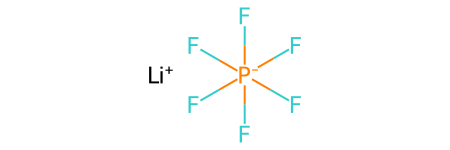

In [15]:
smiles = '[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F'
smiles = '[Li+].F[P-](F)(F)(F)(F)F'
Chem.MolFromSmiles(smiles)

In [16]:
sym, pos, _ = build_complex_from_multifragment(smiles, n_confs=500, min_sep=1.5)
pos_ = xtb_optimize(sym, pos, charge=0, mult=1, solvent='thf', fmax=0.02, steps=500)
ase_mol = Atoms(positions=pos_, symbols=sym)

[18:15:02] UFFTYPER: Warning: hybridization set to SP3 for atom 1
[18:15:02] UFFTYPER: Unrecognized charge state for atom: 1
[18:16:17] UFFTYPER: Warning: hybridization set to SP3 for atom 1
[18:16:17] UFFTYPER: Unrecognized charge state for atom: 1
normal termination of xtb
normal termination of xtb
normal termination of xtb
normal termination of xtb
normal termination of xtb
normal termination of xtb
normal termination of xtb
normal termination of xtb
normal termination of xtb
normal termination of xtb
normal termination of xtb
normal termination of xtb
normal termination of xtb
normal termination of xtb
normal termination of xtb
normal termination of xtb
normal termination of xtb
normal termination of xtb
normal termination of xtb
normal termination of xtb
normal termination of xtb
normal termination of xtb
normal termination of xtb
normal termination of xtb
normal termination of xtb
normal termination of xtb
normal termination of xtb
normal termination of xtb
normal termination of 

In [17]:
nv.show_ase(ase_mol)
# pos_
view(ase_mol)

<Popen: returncode: None args: ['/Users/riteshkumar/codes/anaconda3/bin/pyth...>

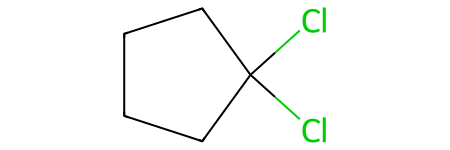

In [ ]:
Chem.MolFromSmiles(df['smiles'][369])
Chem.MolFromSmiles(df['smiles'][377])
Chem.MolFromSmiles(df['smiles'][396])

In [27]:
IPythonConsole.drawMol3D(gen_3d_mol(df['smiles'][369]))
IPythonConsole.drawMol3D(gen_3d_mol(df['smiles'][396]))
IPythonConsole.drawMol3D(gen_3d_mol(df['smiles'][377]))

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [10]:
smile = df['smiles'][69]
# Decide per molecule if you want xTB refinement
sym, pos, _, _ = rdkit_best_conformer(smile, n_confs=200)
pos

array([[-2.69610118e+00, -4.22881065e+00,  9.45279163e-01],
       [-4.04048111e+00, -4.65797377e+00,  7.66930665e-01],
       [-4.75395526e+00, -3.89816103e+00, -2.15778720e-01],
       [-5.06970978e+00, -2.47128621e+00,  2.41671398e-01],
       [-3.93881309e+00, -1.62490691e+00,  9.77202988e-04],
       [-4.15802386e+00, -2.74810270e-01,  4.16680303e-01],
       [-4.84507029e+00,  5.54218681e-01, -6.71025737e-01],
       [-5.23387885e+00,  1.85930738e+00, -2.42027405e-01],
       [-4.17233161e+00,  2.74796360e+00,  1.22061631e-01],
       [-3.25257497e+00,  3.12214951e+00, -1.04207570e+00],
       [-2.27037106e+00,  2.09525977e+00, -1.22396068e+00],
       [-1.34955072e+00,  2.39891792e+00, -2.27306292e+00],
       [-2.56362249e-01,  3.33041068e+00, -1.79562870e+00],
       [-6.82215794e-02,  4.54794943e+00, -2.47536706e+00],
       [ 9.16954190e-01,  5.44905981e+00, -2.07335135e+00],
       [ 1.72773724e+00,  5.14785908e+00, -9.84899867e-01],
       [ 1.55819888e+00,  3.94286332e+00

In [ ]:
ase_mol = Atoms(symbols=sym, positions=pos)
# view(ase_mol)  # This will open an interactive viewer in a new window
nv.show_ase(ase_mol)

In [ ]:
# Optional: refine with xTB (fast) or CREST (thorough)
try:
    pos = xtb_optimize(sym, pos, charge=0, mult=1, solvent='thf')
    # or: pos = crest_best_geometry(sym, pos, charge=0, solvent='thf', ncores=nprocs)
except Exception as e:
    print(f"xTB/CREST refinement failed, using RDKit pose. Reason: {e}")

mol_pym = Molecule(sym, pos)
# build GaussianInput as you already do

In [51]:
params = _xtb_ase_parameters(charge=0, mult=1, steps=200, solvent='thf')
# params = _xtb_ase_parameters(steps=250, solvent='thf')
calc = XTB(method='GFN2-xTB',
           parameters=params)
        #    charge=charge,
            # max_iterations=200)
            # solvent='thf')
atoms = Atoms(symbols=sym, positions=pos)
atoms.calc = calc

In [52]:
dyn = BFGS(atoms, logfile=None)
dyn.run(fmax=0.02, steps=200)
pos = atoms.get_positions()

normal termination of xtb
Note: The following floating-point exceptions are signalling: IEEE_UNDERFLOW_FLAG
normal termination of xtb
Note: The following floating-point exceptions are signalling: IEEE_UNDERFLOW_FLAG
normal termination of xtb
Note: The following floating-point exceptions are signalling: IEEE_UNDERFLOW_FLAG
normal termination of xtb
Note: The following floating-point exceptions are signalling: IEEE_UNDERFLOW_FLAG
normal termination of xtb
Note: The following floating-point exceptions are signalling: IEEE_UNDERFLOW_FLAG
normal termination of xtb
Note: The following floating-point exceptions are signalling: IEEE_UNDERFLOW_FLAG
normal termination of xtb
Note: The following floating-point exceptions are signalling: IEEE_UNDERFLOW_FLAG
normal termination of xtb
Note: The following floating-point exceptions are signalling: IEEE_UNDERFLOW_FLAG
normal termination of xtb
Note: The following floating-point exceptions are signalling: IEEE_UNDERFLOW_FLAG
normal termination of xtb
No

In [ ]:
ase_mol = Atoms(symbols=sym, positions=pos)
# view(ase_mol)  # This will open an interactive viewer in a new window
nv.show_ase(ase_mol)

In [ ]:
nv.show_pymatgen(mol_pym)

Generate Gaussian input files